# Faisalabad AQI Forecasting

Multi-horizon (24h / 48h / 72h) air quality prediction pipeline, with MLflow
experiment tracking and Hopsworks model registry integration.


## Setup

In [1]:
import os
import joblib
import hopsworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("aqi_forecasting")


2026/09/05 00:20:17 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/05 00:20:17 INFO mlflow.store.db.utils: Updating database tables
2026/09/05 00:20:19 INFO mlflow.tracking.fluent: Experiment with name 'aqi_forecasting' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:f:/laptop/AQI_Predictor/Notebooks/mlruns/1', creation_time=1788549619819, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1788549619819, lifecycle_stage='active', name='aqi_forecasting', tags={}, trace_location=None, workspace='default'>

## 1. Data collection

In [2]:
def get_data_from_feature_store():
    """Connect to Hopsworks and pull the latest AQI feature group as a dataframe."""
    project = hopsworks.login()
    # fs = project.get_feature_store(name="aqi_predictor_fsd_featurestore")
    # fg = fs.get_feature_group("weather_aqi_hourly", version=6)

    # data = fg.read(online=True)
    # data["time"] = pd.to_datetime(data["time"])
    # data = data.sort_values("time").reset_index(drop=True)
    return project




project = get_data_from_feature_store()
# print(f"rows: {len(df)}, columns: {df.shape[1]}")
# print(f"date range: {df['time'].min()} to {df['time'].max()}")


2026-09-05 00:20:20,189 INFO: Initializing external client
2026-09-05 00:20:20,190 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-09-05 00:20:26,503 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/42119


In [5]:
snapshot_path = "aqi_snapshot.parquet"

In [ ]:
# save a snapshot so results stay comparable across reruns
# (the online feature store keeps growing every hour)

df.to_parquet(snapshot_path)
print(f"saved snapshot: {snapshot_path}, {len(df)} rows")


## 2. Data cleaning

In [7]:
df = pd.read_parquet(snapshot_path)
target_cols = ["target_aqi_24h", "target_aqi_48h", "target_aqi_72h"]

print(df.shape)
print(df.isna().sum().loc[lambda s: s > 0])
print("duplicate rows:", df.duplicated().sum())


(17592, 45)
Series([], dtype: int64)
duplicate rows: 0


In [8]:
def clean_data(data, targets):
    """Drop rows with missing targets (recent rows with no future value yet) and duplicates."""
    rows_before = len(data)
    data = data.dropna(subset=targets).reset_index(drop=True)
    data = data.drop_duplicates().reset_index(drop=True)
    print(f"dropped {rows_before - len(data)} rows, {len(data)} remaining")
    return data


df = clean_data(df, target_cols)


dropped 0 rows, 17592 remaining


## 3. Exploratory data analysis

In [9]:
numeric_cols = df.select_dtypes(include="number")
print(numeric_cols.agg(["min", "max", "mean", "std", "median"]).T)


                             min          max          mean         std  \
temperature_2m          2.400000    46.900000  2.539485e+01    8.533641   
relative_humidity_2m    4.000000   100.000000  5.856548e+01   22.383692   
surface_pressure      969.400000  1005.500000  9.863164e+02    7.027610   
wind_speed_10m          0.000000    38.400000  6.439853e+00    3.376699   
wind_direction_10m      1.000000   360.000000  1.630279e+02   97.453504   
pm2_5                   3.400000   486.200000  8.286771e+01   66.726711   
pm10                    3.400000   804.700000  1.106503e+02   80.572785   
nitrogen_dioxide        0.000000   187.000000  3.749816e+01   33.031952   
ozone                   0.000000   257.000000  8.504593e+01   61.590694   
us_aqi                 69.000000   437.000000  1.663313e+02   54.714755   
wind_u                -31.066253    20.353490 -1.647225e+00    5.212757   
wind_v                -26.588439    21.825889  4.115912e-01    4.777071   
hour                    0

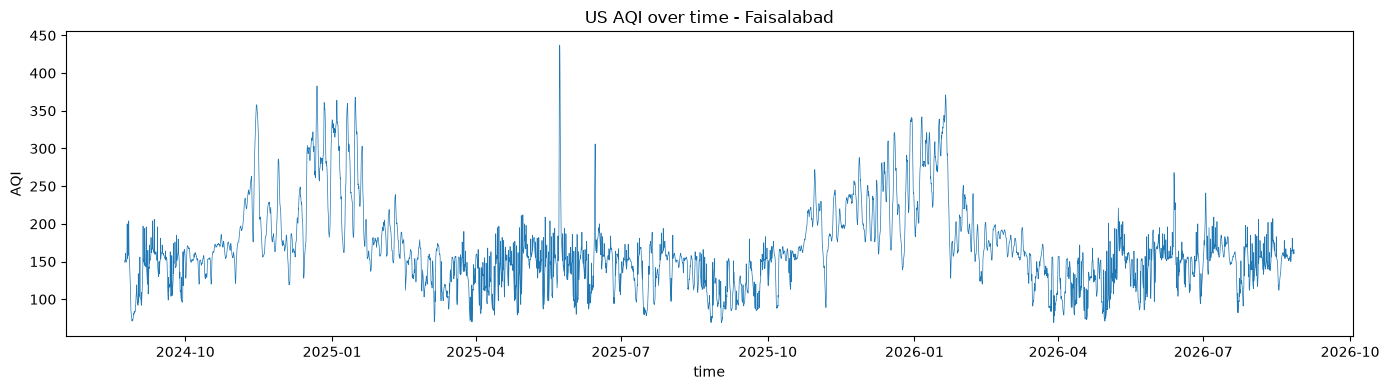

In [10]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["time"], df["us_aqi"], linewidth=0.5)
ax.set_title("US AQI over time - Faisalabad")
ax.set_xlabel("time")
ax.set_ylabel("AQI")
plt.tight_layout()
plt.savefig("aqi_over_time.png", dpi=150)
plt.show()


This figure shows that the AQI is high in Faisalabad mostly in Winter and biggest cause is Industy of Faisalabad including Textile Industry

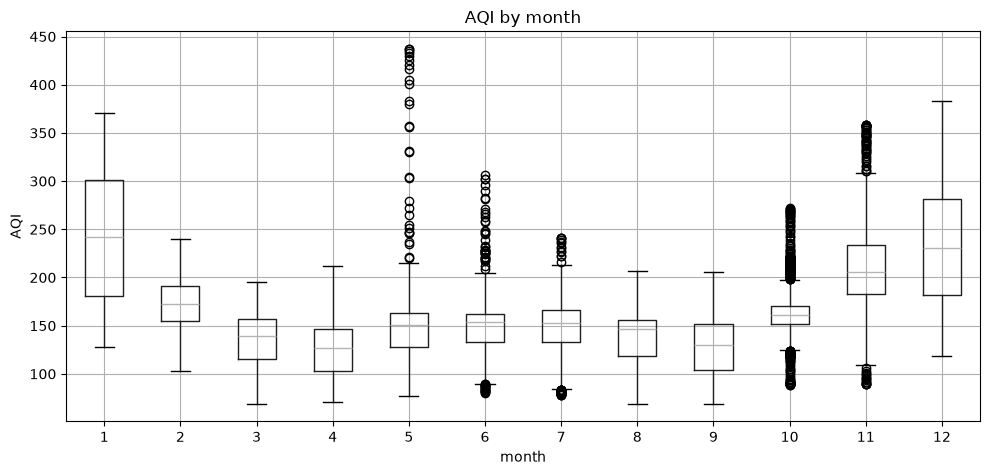

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
df.boxplot(column="us_aqi", by="month", ax=ax)
ax.set_title("AQI by month")
ax.set_xlabel("month")
ax.set_ylabel("AQI")
plt.suptitle("")
plt.tight_layout()
plt.savefig("aqi_by_month.png", dpi=150)
plt.show()


## 4. Train / validation / test split

A gap of 72 rows is left after each split boundary, since the longest target
looks 72 hours ahead. Without the gap, a training row near the boundary could
have a target value that falls inside the validation or test period.

In [12]:
def split_data(data, feature_cols, targets, train_frac=0.8, val_frac=0.9, gap=72):
    """Split a time-ordered dataframe into train/val/test with a leakage gap between each part."""
    x = data[feature_cols]
    y = data[targets]
    n = len(data)
    train_end = int(n * train_frac)
    val_end = int(n * val_frac)

    x_train, y_train = x.iloc[:train_end], y.iloc[:train_end]
    x_val, y_val = x.iloc[train_end + gap:val_end], y.iloc[train_end + gap:val_end]
    x_test, y_test = x.iloc[val_end + gap:], y.iloc[val_end + gap:]
    return x_train, y_train, x_val, y_val, x_test, y_test, train_end, val_end


metadata_cols = ["time", "city"]
feature_cols = [c for c in df.columns if c not in target_cols + metadata_cols]

x_train, y_train, x_val, y_val, x_test, y_test, train_end, val_end = split_data(
    df, feature_cols, target_cols
)

print(f"train: {df['time'].iloc[0]} to {df['time'].iloc[train_end-1]} ({len(x_train)} rows)")
print(f"val:   {df['time'].iloc[train_end+72]} to {df['time'].iloc[val_end-1]} ({len(x_val)} rows)")
print(f"test:  {df['time'].iloc[val_end+72]} to {df['time'].iloc[-1]} ({len(x_test)} rows)")

train_std = x_train["us_aqi"].std()
test_std = x_test["us_aqi"].std()
print(f"\nus_aqi std - train: {train_std:.1f}, test: {test_std:.1f}")
if abs(train_std - test_std) / train_std > 0.3:
    print("test period has noticeably different variance than train - "
          "expect R2 to move around more than MAE across experiments")


train: 2024-08-24 00:00:00 to 2026-04-02 08:00:00 (14073 rows)
val:   2026-04-05 09:00:00 to 2026-06-14 15:00:00 (1687 rows)
test:  2026-06-17 16:00:00 to 2026-08-26 23:00:00 (1688 rows)

us_aqi std - train: 58.1, test: 23.0
test period has noticeably different variance than train - expect R2 to move around more than MAE across experiments


## 5. Feature selection

In [13]:
def top_correlated_features(data, targets, n=15):
    """Rank features by Spearman correlation with each target, using train rows only."""
    numeric = data.select_dtypes(include="number")
    corr = numeric.corr(method="spearman")
    result = {}
    for target in targets:
        ranked = corr[target].drop(labels=targets, errors="ignore").abs().sort_values(ascending=False)
        result[target] = ranked.head(n)
    return result


train_df = df.iloc[:train_end]
top_features = top_correlated_features(train_df, target_cols)
for target, ranked in top_features.items():
    print(f"\n{target}")
    print(ranked)



target_aqi_24h
us_aqi                  0.822030
us_aqi_lag_1h           0.811123
pm2_5_roll_mean_24h     0.805112
us_aqi_roll_mean_24h    0.754831
us_aqi_roll_min_24h     0.749465
us_aqi_roll_max_24h     0.725243
pm2_5_roll_mean_6h      0.717139
us_aqi_lag_24h          0.713927
pm2_5                   0.712482
pm2_5_roll_std_24h      0.700501
pm2_5_lag_1h            0.692631
us_aqi_lag_48h          0.675009
cos_month               0.666451
us_aqi_lag_72h          0.658297
surface_pressure        0.613615
Name: target_aqi_24h, dtype: float64

target_aqi_48h
us_aqi                  0.714113
us_aqi_lag_1h           0.708401
pm2_5_roll_mean_24h     0.703071
us_aqi_roll_mean_24h    0.687368
us_aqi_roll_min_24h     0.678531
us_aqi_lag_24h          0.675493
cos_month               0.669705
us_aqi_lag_48h          0.660692
us_aqi_roll_max_24h     0.655338
us_aqi_lag_72h          0.646114
pm2_5_roll_std_24h      0.631162
surface_pressure        0.612762
pm2_5_roll_mean_6h      0.594253
pm2_5  

In [14]:
final_features = [
    "us_aqi", "us_aqi_lag_1h", "pm25_pm10_ratio",
    "pm2_5", "pm2_5_lag_1h", "pm2_5_roll_mean_6h", "pm2_5_roll_mean_24h",
    "pm2_5_roll_std_24h", "pm10",
    "us_aqi_lag_24h", "us_aqi_lag_48h", "us_aqi_lag_72h",
    "us_aqi_roll_mean_24h", "us_aqi_roll_min_24h", "us_aqi_roll_max_24h", "us_aqi_roll_std_24h",
    "temperature_2m", "relative_humidity_2m", "surface_pressure",
    "wind_speed_10m", "wind_u", "wind_v",
    "is_burning_season",
    "cos_month", "sin_month", "cos_hour", "sin_hour", "is_weekend",
]

train_x = x_train[final_features]
val_x = x_val[final_features]
test_x = x_test[final_features]

train_y_24h, val_y_24h, test_y_24h = y_train["target_aqi_24h"], y_val["target_aqi_24h"], y_test["target_aqi_24h"]
train_y_48h, val_y_48h, test_y_48h = y_train["target_aqi_48h"], y_val["target_aqi_48h"], y_test["target_aqi_48h"]
train_y_72h, val_y_72h, test_y_72h = y_train["target_aqi_72h"], y_val["target_aqi_72h"], y_test["target_aqi_72h"]

print(f"using {len(final_features)} features")


using 28 features


## 6. Evaluation helper and MLflow logging

In [15]:
def score_predictions(y_true, y_pred):
    """Return the standard set of regression metrics as a plain dict."""
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": root_mean_squared_error(y_true, y_pred),
        "mape": mean_absolute_percentage_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }

import numpy as np
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
import mlflow.catboost
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

def train_and_log(model, model_name, horizon, x_tr, y_tr, x_te, y_te, params=None):
    # 1. Fit the model
    model.fit(x_tr, y_tr)
    
    # 2. Predict on test set
    preds = model.predict(x_te)
    
    # 3. Calculate exact performance metrics
    metrics = {
        "mae": float(mean_absolute_error(y_te, preds)),
        "rmse": float(np.sqrt(mean_squared_error(y_te, preds))),
        "mape": float(mean_absolute_percentage_error(y_te, preds)),
        "r2": float(r2_score(y_te, preds)),
    }
    
    # 4. MLflow Experiment Tracking
    mlflow.log_param("n_features", x_tr.shape[1])
    if params:
        mlflow.log_params(params)
    mlflow.log_metrics(metrics)
    
    # 5. Route logging to native MLflow flavors to prevent serialization & deprecation errors
    cls_name = model.__class__.__name__
    
    if "XGB" in cls_name:
        mlflow.xgboost.log_model(
            model, 
            name="model", 
            pip_requirements=["xgboost", "mlflow"]
        )
    elif "LGBM" in cls_name:
        mlflow.lightgbm.log_model(
            model, 
            name="model", 
            pip_requirements=["lightgbm", "mlflow"]
        )
    elif "CatBoost" in cls_name:
        mlflow.catboost.log_model(
            model, 
            name="model", 
            pip_requirements=["catboost", "mlflow"]
        )
    else:
        # scikit-learn estimators (LinearRegression, Ridge, RandomForest, etc.)
        mlflow.sklearn.log_model(
            sk_model=model,
            name="model",
            serialization_format="cloudpickle",
            pip_requirements=["scikit-learn", "mlflow"]
        )
    
    # 6. Append metadata for run aggregation
    metrics["model"] = model_name
    metrics["horizon"] = horizon
    
    return metrics, model


In [16]:
import os

# Disable automatic deep requirement capture across all logging calls
os.environ["MLFLOW_REQUIREMENTS_INFERENCE_TIMEOUT"] = "1"

## 7. Baseline - persistence

In [17]:
def persistence_baseline(x_te, y_te, horizon):
    """Score the naive 'value now = value later' baseline and log it as an MLflow run."""
    if isinstance(x_te, pd.DataFrame):
        pred = x_te["us_aqi"]
    else:
        pred = x_te[:, 0]
    metrics = score_predictions(y_te, pred)
    loggable_metrics = {k: float(v) for k, v in metrics.items()}
    with mlflow.start_run(run_name=f"baseline_{horizon}"):
        mlflow.log_param("model", "persistence")
        mlflow.log_param("horizon", horizon)
        mlflow.log_metrics(loggable_metrics)
        
    metrics["model"] = "persistence"
    metrics["horizon"] = horizon
    
    return metrics


baseline_24h = persistence_baseline(test_x, test_y_24h, "24h")
print(baseline_24h)

{'mae': 17.308649289099527, 'rmse': 23.46305202710296, 'mape': 0.12191594024645809, 'r2': -0.04620641170953421, 'model': 'persistence', 'horizon': '24h'}


## 8. Model comparison - 24h

In [18]:
scaler = RobustScaler()
train_x_scaled = scaler.fit_transform(train_x)
test_x_scaled = scaler.transform(test_x)

scores_24h = [baseline_24h]

linear_metrics, linear_model = train_and_log(
    LinearRegression(), "linear_regression", "24h", train_x_scaled, train_y_24h, test_x_scaled, test_y_24h
)
scores_24h.append(linear_metrics)

ridge_metrics, ridge_model = train_and_log(
    Ridge(alpha=1.0, random_state=42), "ridge", "24h", train_x_scaled, train_y_24h, test_x_scaled, test_y_24h
)
scores_24h.append(ridge_metrics)

tree_metrics, tree_model = train_and_log(
    DecisionTreeRegressor(max_depth=5, min_samples_leaf=20, random_state=42),
    "decision_tree", "24h", train_x, train_y_24h, test_x, test_y_24h
)
scores_24h.append(tree_metrics)

forest_metrics, forest_model = train_and_log(
    RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=10, random_state=42, n_jobs=-1),
    "random_forest", "24h", train_x, train_y_24h, test_x, test_y_24h
)
scores_24h.append(forest_metrics)

xgb_metrics, xgb_model = train_and_log(
    XGBRegressor(n_estimators=500, max_depth=4, learning_rate=0.05, subsample=0.8,
                 colsample_bytree=0.8, min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0,
                 random_state=42),
    "xgboost", "24h", train_x, train_y_24h, test_x, test_y_24h
)
scores_24h.append(xgb_metrics)

lgbm_metrics, lgbm_model = train_and_log(
    LGBMRegressor(n_estimators=500, max_depth=4, learning_rate=0.03, subsample=0.8,
                  colsample_bytree=0.8, random_state=42, verbosity=-1),
    "lightgbm", "24h", train_x, train_y_24h, test_x, test_y_24h
)
scores_24h.append(lgbm_metrics)

cat_metrics, cat_model = train_and_log(
    CatBoostRegressor(iterations=500, depth=4, learning_rate=0.03, random_state=42, verbose=False),
    "catboost", "24h", train_x, train_y_24h, test_x, test_y_24h
)
scores_24h.append(cat_metrics)

results_24h = pd.DataFrame(scores_24h).sort_values("mae").reset_index(drop=True)
print(results_24h.to_string(index=False))


2026/09/05 00:22:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/09/05 00:22:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/09/05 00:22:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mec

      mae      rmse     mape        r2             model horizon
14.146903 18.334680 0.094701  0.361156          catboost     24h
14.364330 18.560676 0.095999  0.345310          lightgbm     24h
14.751730 18.885615 0.098278  0.322186           xgboost     24h
14.922724 19.649757 0.100524  0.266225     random_forest     24h
15.581801 19.808815 0.103237  0.254298 linear_regression     24h
15.582078 19.809178 0.103236  0.254271             ridge     24h
16.951443 22.506845 0.115033  0.037330     decision_tree     24h
17.308649 23.463052 0.121916 -0.046206       persistence     24h


In [19]:
baseline_mae = results_24h.loc[results_24h["model"] == "persistence", "mae"].values[0]
results_24h["beats_baseline"] = results_24h["mae"] < baseline_mae
print(results_24h[["model", "mae", "r2", "beats_baseline"]].to_string(index=False))


            model       mae        r2  beats_baseline
         catboost 14.146903  0.361156            True
         lightgbm 14.364330  0.345310            True
          xgboost 14.751730  0.322186            True
    random_forest 14.922724  0.266225            True
linear_regression 15.581801  0.254298            True
            ridge 15.582078  0.254271            True
    decision_tree 16.951443  0.037330            True
      persistence 17.308649 -0.046206           False


## 9. Hyperparameter tuning + time-series cross-validation

In [20]:
xgb_grid = {
    "n_estimators": [200, 300, 500, 800],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "reg_alpha": [0, 0.1, 0.5, 1.0],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0],
}

cat_grid = {
    "iterations": [300, 500, 800, 1200],
    "depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "subsample": [0.6, 0.7, 0.8, 1.0],
    "border_count": [32, 64, 128],
}
def tune_model(base_model, param_distributions, horizon, model_name, x_tr, y_tr, x_te, y_te, n_iter=10, cv=5):
    if mlflow.active_run():
        mlflow.end_run()

    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_distributions,
        n_iter=n_iter,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        random_state=42,
        n_jobs=-1
    )
    search.fit(x_tr, y_tr)
    
    best_model = search.best_estimator_
    pred = best_model.predict(x_te)
    metrics = score_predictions(y_te, pred)

    with mlflow.start_run(run_name=f"{model_name}_tuned_{horizon}"):
        mlflow.log_param("model", model_name)
        mlflow.log_param("horizon", horizon)
        mlflow.log_params(search.best_params_)
        mlflow.log_metrics(metrics)

        cls_name = best_model.__class__.__name__
        if "XGB" in cls_name:
            mlflow.xgboost.log_model(best_model, name="model", pip_requirements=["xgboost", "mlflow"])
        elif "LGBM" in cls_name:
            mlflow.lightgbm.log_model(best_model, name="model", pip_requirements=["lightgbm", "mlflow"])
        elif "CatBoost" in cls_name:
            mlflow.catboost.log_model(best_model, name="model", pip_requirements=["catboost", "mlflow"])
        else:
            mlflow.sklearn.log_model(
                sk_model=best_model,
                name="model",
                serialization_format="cloudpickle",
                pip_requirements=["scikit-learn", "mlflow"]
            )

    metrics["model"] = f"{model_name}_tuned"
    metrics["horizon"] = horizon
    
    return metrics, best_model

In [21]:
best_xgb_24h = tune_model(XGBRegressor(random_state=42), xgb_grid, "24h", "xgboost", train_x, train_y_24h, test_x, test_y_24h)
best_cat_24h = tune_model(CatBoostRegressor(random_state=42, verbose=False), cat_grid, "24h", "catboost", train_x, train_y_24h, test_x, test_y_24h)


In [22]:
def cross_validate(model_class, params, x_data, y_data, horizon, model_name):
    """Score a model across 5 rolling time-series folds and log the fold averages to MLflow."""
    clean_params = {k: v for k, v in params.items() if k not in ("random_state", "verbose")}
    splitter = TimeSeriesSplit(n_splits=5, gap=72)
    fold_rows = []

    for fold, (tr_idx, te_idx) in enumerate(splitter.split(x_data)):
        fold_model = model_class(**clean_params, random_state=42, verbose=False)
        fold_model.fit(x_data.iloc[tr_idx], y_data.iloc[tr_idx])
        pred = fold_model.predict(x_data.iloc[te_idx])
        fold_rows.append({
            "fold": fold,
            "mae": mean_absolute_error(y_data.iloc[te_idx], pred),
            "r2": r2_score(y_data.iloc[te_idx], pred),
        })

    fold_df = pd.DataFrame(fold_rows)
    mean_mae = fold_df["mae"].mean()
    mean_r2 = fold_df["r2"].mean()

    with mlflow.start_run(run_name=f"{model_name}_cv_{horizon}"):
        mlflow.log_param("model", model_name)
        mlflow.log_param("horizon", horizon)
        mlflow.log_metric("cv_mean_mae", mean_mae)
        mlflow.log_metric("cv_mean_r2", mean_r2)

    print(fold_df.to_string(index=False))
    print(f"mean mae: {mean_mae:.2f}, mean r2: {mean_r2:.3f}")
    return fold_df

metrics_xgb_24h, best_xgb_24h = tune_model(
    XGBRegressor(random_state=42), xgb_grid, "24h", "xgboost", train_x, train_y_24h, test_x, test_y_24h
)

metrics_cat_24h, best_cat_24h = tune_model(
    CatBoostRegressor(random_state=42, verbose=False), cat_grid, "24h", "catboost", train_x, train_y_24h, test_x, test_y_24h
)

cv_xgb_24h = cross_validate(XGBRegressor, best_xgb_24h.get_params(), train_x, train_y_24h, "24h", "xgboost")
cv_cat_24h = cross_validate(CatBoostRegressor, best_cat_24h.get_params(), train_x, train_y_24h, "24h", "catboost")


Parameters: { "verbose" } are not used.

Parameters: { "verbose" } are not used.

Parameters: { "verbose" } are not used.

Parameters: { "verbose" } are not used.

Parameters: { "verbose" } are not used.



 fold       mae       r2
    0 30.713722 0.581054
    1 21.050424 0.177591
    2 18.547929 0.380233
    3 22.806884 0.629129
    4 21.437357 0.807478
mean mae: 22.91, mean r2: 0.515
 fold       mae       r2
    0 33.357244 0.526813
    1 21.218868 0.187373
    2 18.055857 0.406571
    3 21.655911 0.651694
    4 22.226373 0.795209
mean mae: 23.30, mean r2: 0.514


In [23]:
importance = pd.Series(best_cat_24h.feature_importances_, index=train_x.columns).sort_values(ascending=False)
print(importance)


pm2_5_roll_mean_24h     8.849633
cos_month               8.567460
pm10                    7.950543
us_aqi                  7.330280
pm2_5                   6.744183
us_aqi_lag_48h          5.491811
wind_speed_10m          5.061849
us_aqi_lag_72h          4.732651
us_aqi_lag_1h           4.268130
surface_pressure        3.579880
cos_hour                3.182449
wind_v                  3.165258
sin_month               3.020721
us_aqi_roll_std_24h     2.850972
us_aqi_lag_24h          2.628794
pm2_5_roll_std_24h      2.252443
sin_hour                2.105585
us_aqi_roll_mean_24h    1.982953
pm25_pm10_ratio         1.867688
us_aqi_roll_min_24h     1.855610
pm2_5_roll_mean_6h      1.851089
us_aqi_roll_max_24h     1.817946
wind_u                  1.789448
is_burning_season       1.729604
is_weekend              1.565961
relative_humidity_2m    1.319209
pm2_5_lag_1h            1.315855
temperature_2m          1.121995
dtype: float64


## 10. 48h and 72h

In [25]:
best_cat_48h = tune_model(CatBoostRegressor(random_state=42, verbose=False), cat_grid, "48h", "catboost", train_x, train_y_48h, test_x, test_y_48h)
best_cat_72h = tune_model(CatBoostRegressor(random_state=42, verbose=False), cat_grid, "72h", "catboost", train_x, train_y_72h, test_x, test_y_72h)

baseline_48h = persistence_baseline(test_x, test_y_48h, "48h")
baseline_72h = persistence_baseline(test_x, test_y_72h, "72h")
# Extract model instance from the returned tuple
cat_model_48h = best_cat_48h[1] if isinstance(best_cat_48h, tuple) else best_cat_48h
cat_model_72h = best_cat_72h[1] if isinstance(best_cat_72h, tuple) else best_cat_72h

cv_cat_48h = cross_validate(CatBoostRegressor, cat_model_48h.get_params(), train_x, train_y_48h, "48h", "catboost")
cv_cat_72h = cross_validate(CatBoostRegressor, cat_model_72h.get_params(), train_x, train_y_72h, "72h", "catboost")

 fold       mae        r2
    0 46.840528  0.170590
    1 28.326537 -0.223202
    2 22.638484  0.035131
    3 30.997068  0.314433
    4 28.707397  0.639471
mean mae: 31.50, mean r2: 0.187
 fold       mae        r2
    0 53.647174 -0.072520
    1 32.533941 -0.489388
    2 23.200992 -0.003167
    3 34.563635  0.160198
    4 31.592204  0.599935
mean mae: 35.11, mean r2: 0.039


In [26]:
runs = mlflow.search_runs(experiment_names=["aqi_forecasting"], order_by=["metrics.mae ASC"])
cols = [c for c in ["tags.mlflow.runName", "params.model", "params.horizon", "metrics.mae", "metrics.r2", "metrics.cv_mean_mae", "metrics.cv_mean_r2"] if c in runs.columns]
print(runs[cols].to_string(index=False))


tags.mlflow.runName params.model params.horizon  metrics.mae  metrics.r2  metrics.cv_mean_mae  metrics.cv_mean_r2
 catboost_tuned_24h     catboost            24h    14.039005    0.385336                  NaN                 NaN
 catboost_tuned_24h     catboost            24h    14.039005    0.385336                  NaN                 NaN
     nimble-sow-418         None           None    14.146903    0.361156                  NaN                 NaN
  xgboost_tuned_24h      xgboost            24h    14.400727    0.332344                  NaN                 NaN
  xgboost_tuned_24h      xgboost            24h    14.400727    0.332344                  NaN                 NaN
       baseline_24h  persistence            24h    17.308649   -0.046206                  NaN                 NaN
 catboost_tuned_48h     catboost            48h    19.496119   -0.119147                  NaN                 NaN
 catboost_tuned_72h     catboost            72h    19.878107   -0.143722                

## 11. Compare every run in MLflow

In [ ]:
runs = mlflow.search_runs(experiment_names=["aqi_forecasting"], order_by=["metrics.mae ASC"])
cols = [c for c in ["tags.mlflow.runName", "params.model", "params.horizon", "metrics.mae", "metrics.r2", "metrics.cv_mean_mae", "metrics.cv_mean_r2"] if c in runs.columns]
print(runs[cols].to_string(index=False))


tags.mlflow.runName params.model params.horizon  metrics.mae  metrics.r2  metrics.cv_mean_mae  metrics.cv_mean_r2
 catboost_tuned_24h     catboost            24h    14.039005    0.385336                  NaN                 NaN
 catboost_tuned_24h     catboost            24h    14.039005    0.385336                  NaN                 NaN
 catboost_tuned_24h     catboost            24h    14.039005    0.385336                  NaN                 NaN
  treasured-elk-167         None           None    14.146903    0.361156                  NaN                 NaN
  xgboost_tuned_24h      xgboost            24h    14.400727    0.332344                  NaN                 NaN
  xgboost_tuned_24h      xgboost            24h    14.400727    0.332344                  NaN                 NaN
  xgboost_tuned_24h      xgboost            24h    14.400727    0.332344                  NaN                 NaN
       baseline_24h  persistence            24h    17.308649   -0.046206                

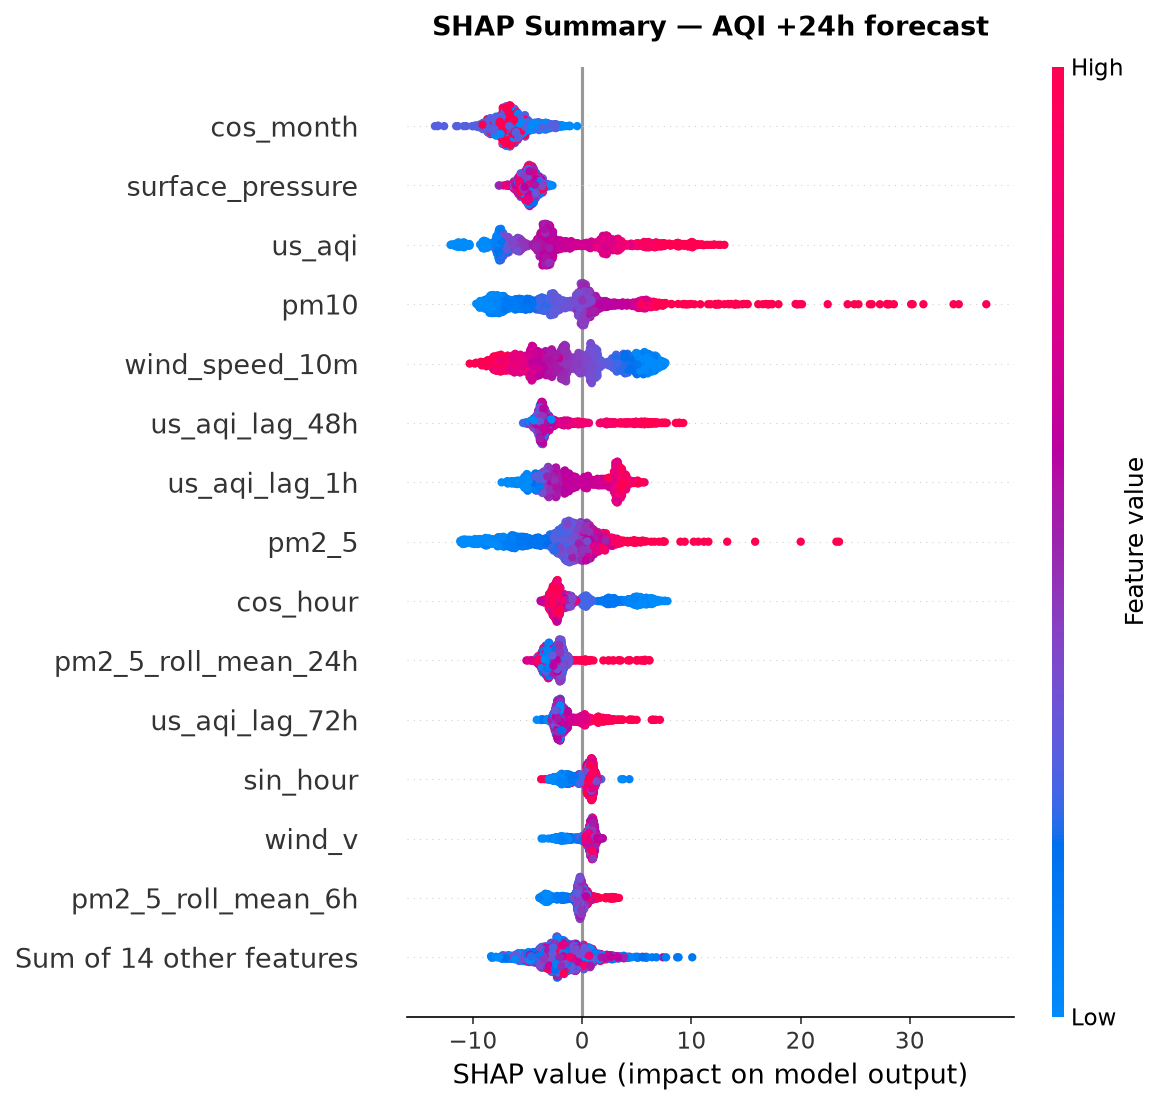

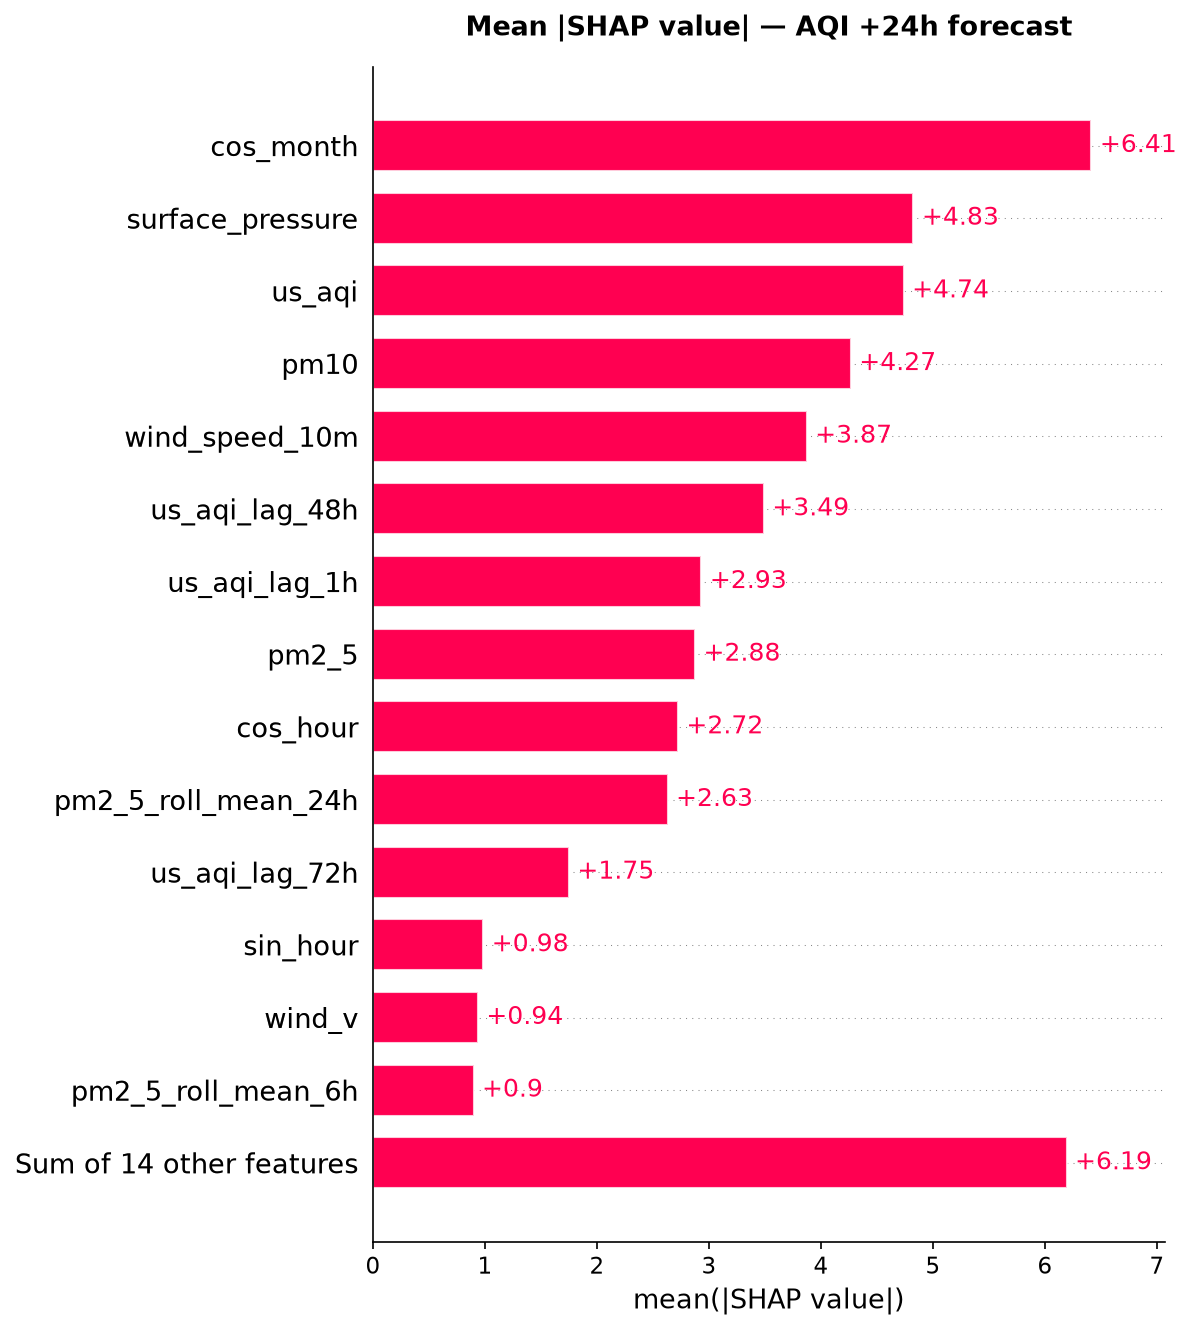

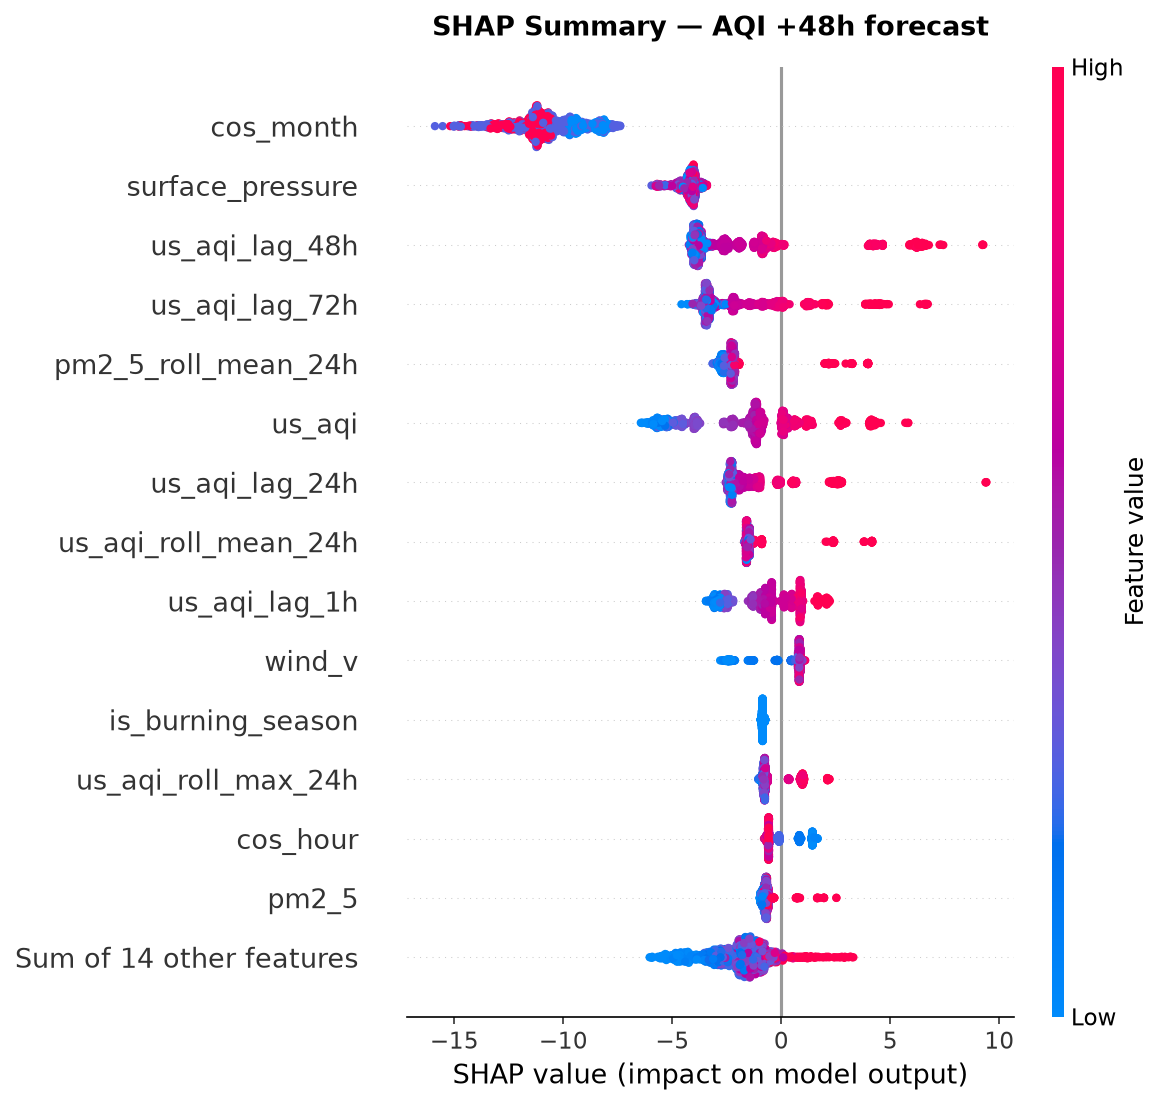

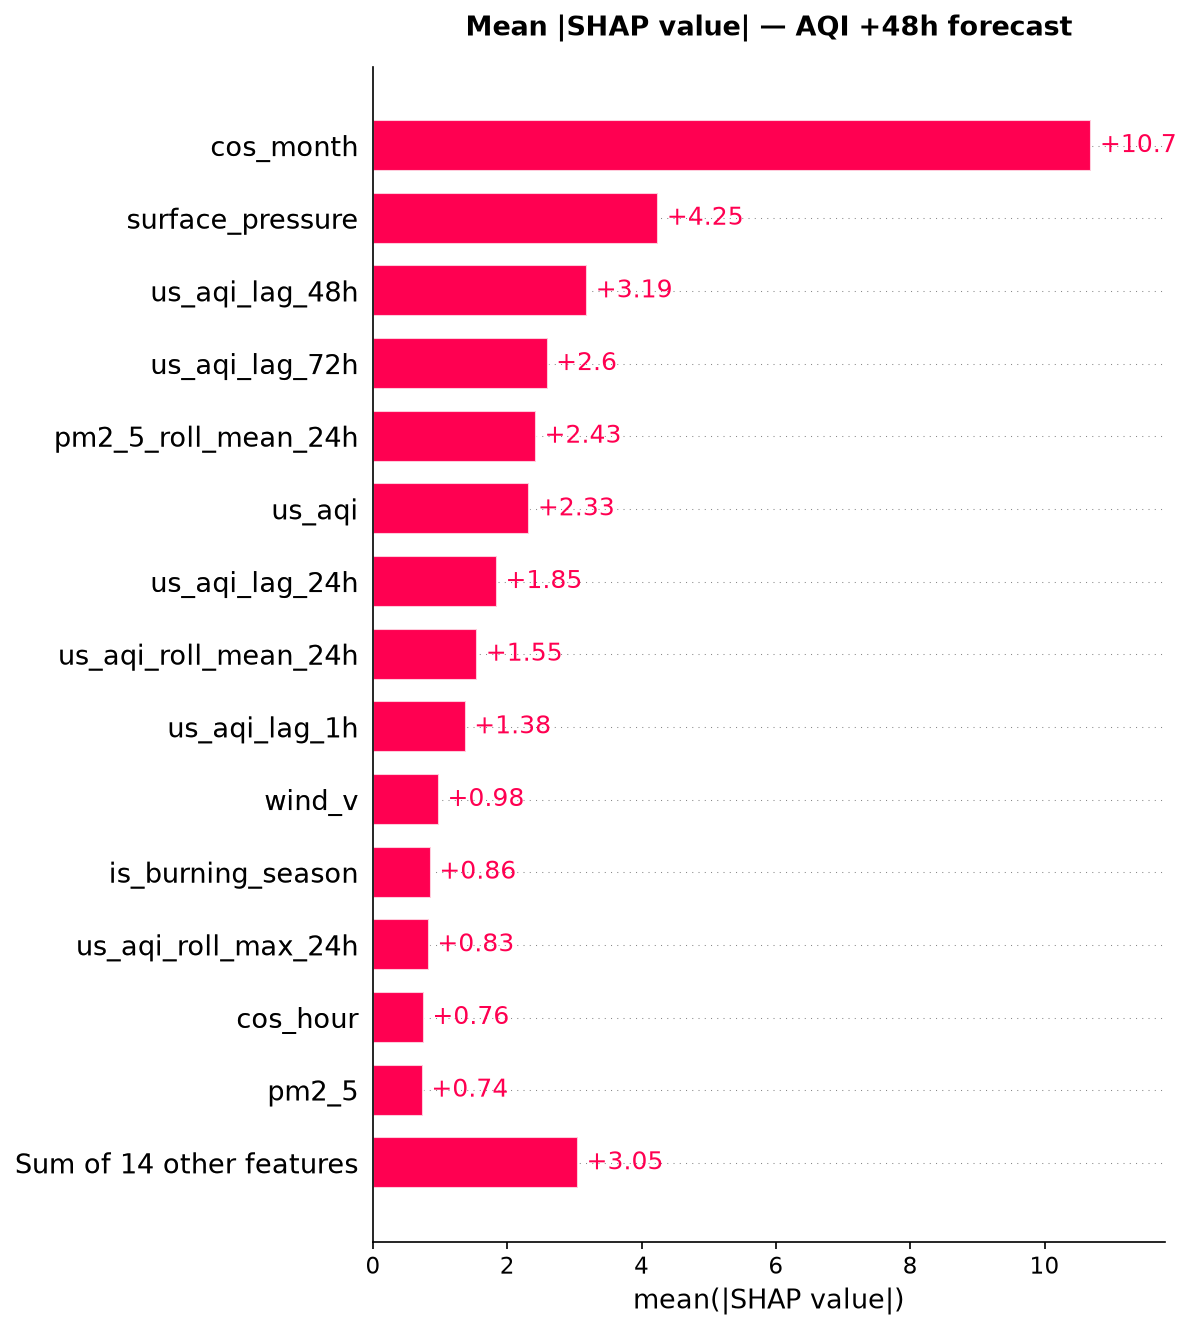

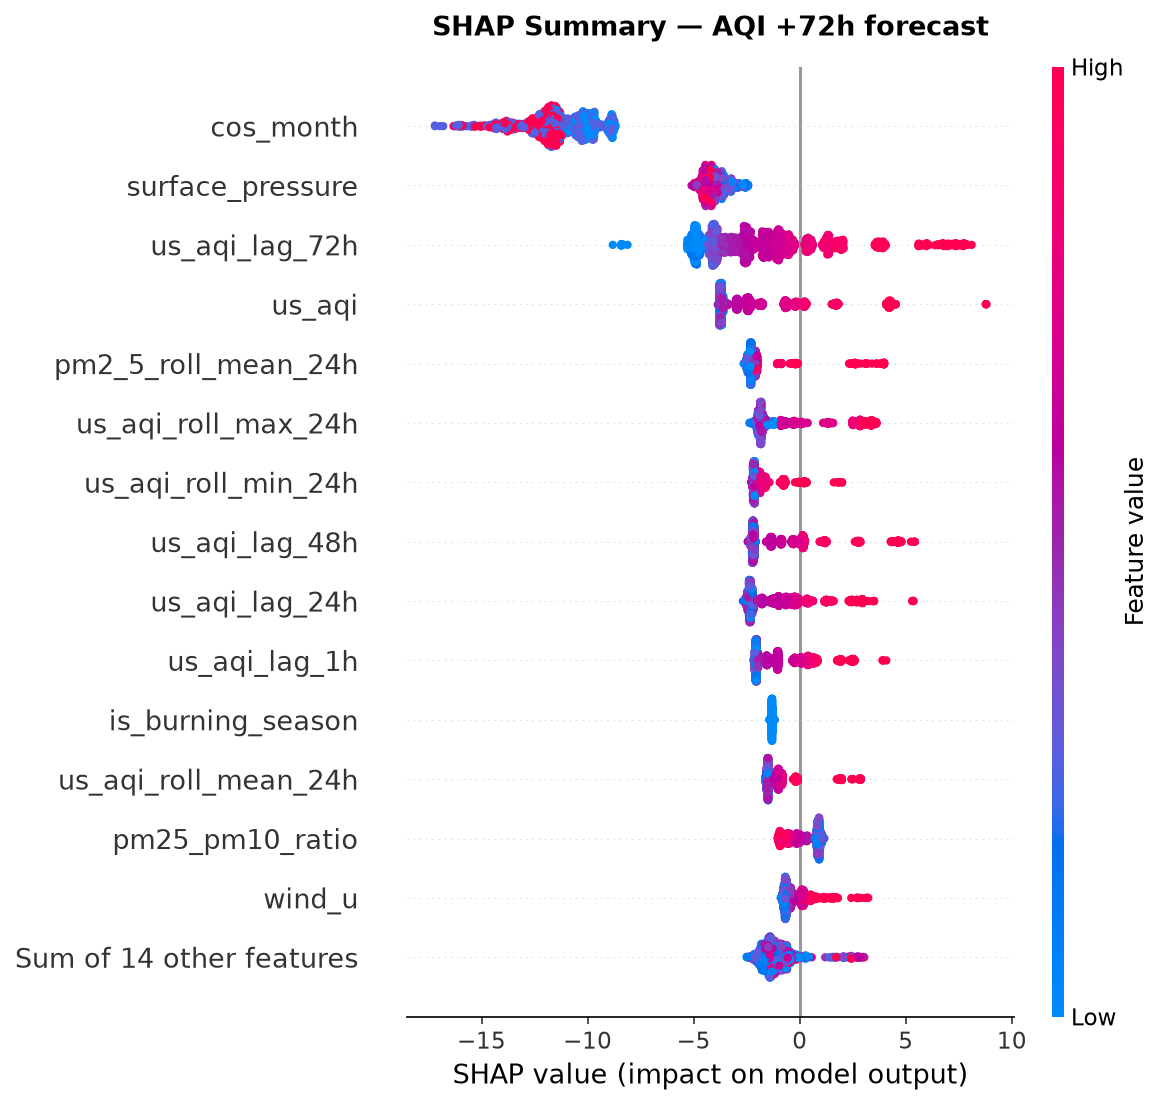

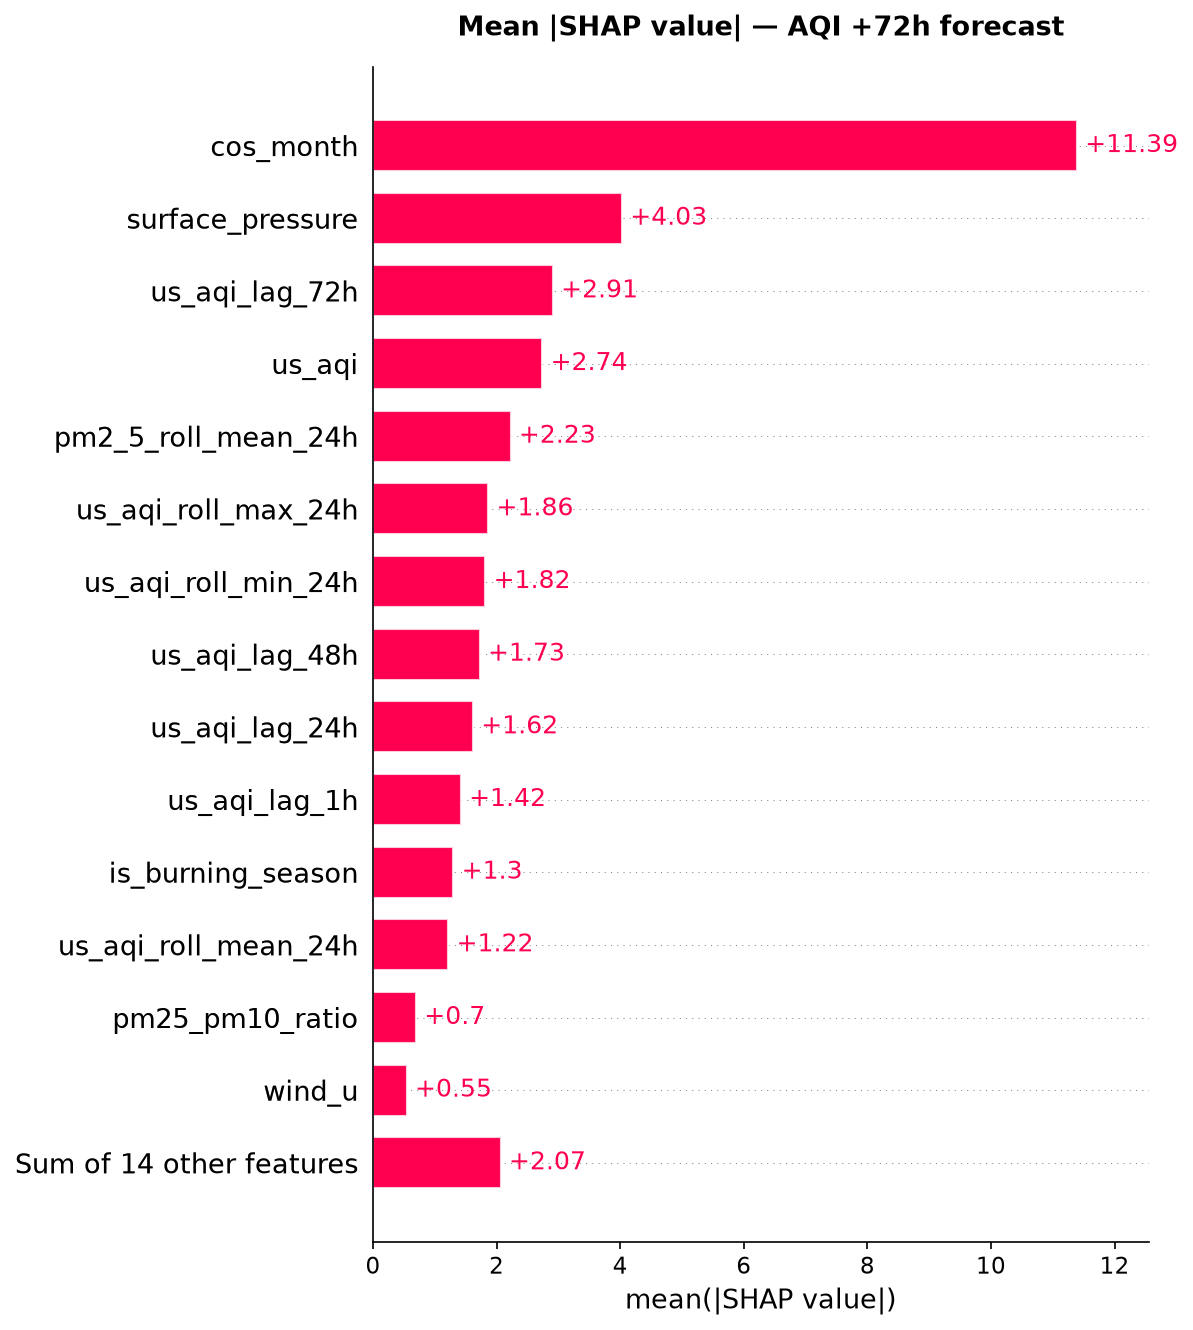

In [27]:
import shap
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})

def explain_model(model, x_data, horizon, save_prefix="shap"):
    """Compute SHAP values for a CatBoost model and render beeswarm + bar + waterfall plots."""
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(x_data)  # Explanation object (new SHAP API)

    # 1. Beeswarm - global view: which features matter, and how their value pushes the prediction
    fig = plt.figure(figsize=(10, 8))
    shap.plots.beeswarm(shap_values, max_display=15, show=False)
    plt.title(f"SHAP Summary — AQI +{horizon} forecast", pad=15)
    plt.tight_layout()
    plt.savefig(f"{save_prefix}_beeswarm_{horizon}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # 2. Bar plot - mean |SHAP value| global importance
    fig = plt.figure(figsize=(10, 7))
    shap.plots.bar(shap_values, max_display=15, show=False)
    plt.title(f"Mean |SHAP value| — AQI +{horizon} forecast", pad=15)
    plt.tight_layout()
    plt.savefig(f"{save_prefix}_bar_{horizon}.png", dpi=150, bbox_inches="tight")
    plt.show()

    return explainer, shap_values


explainer_24h, shap_values_24h = explain_model(best_cat_24h, test_x, "24h")
explainer_48h, shap_values_48h = explain_model(cat_model_48h, test_x, "48h")
explainer_72h, shap_values_72h = explain_model(cat_model_72h, test_x, "72h")

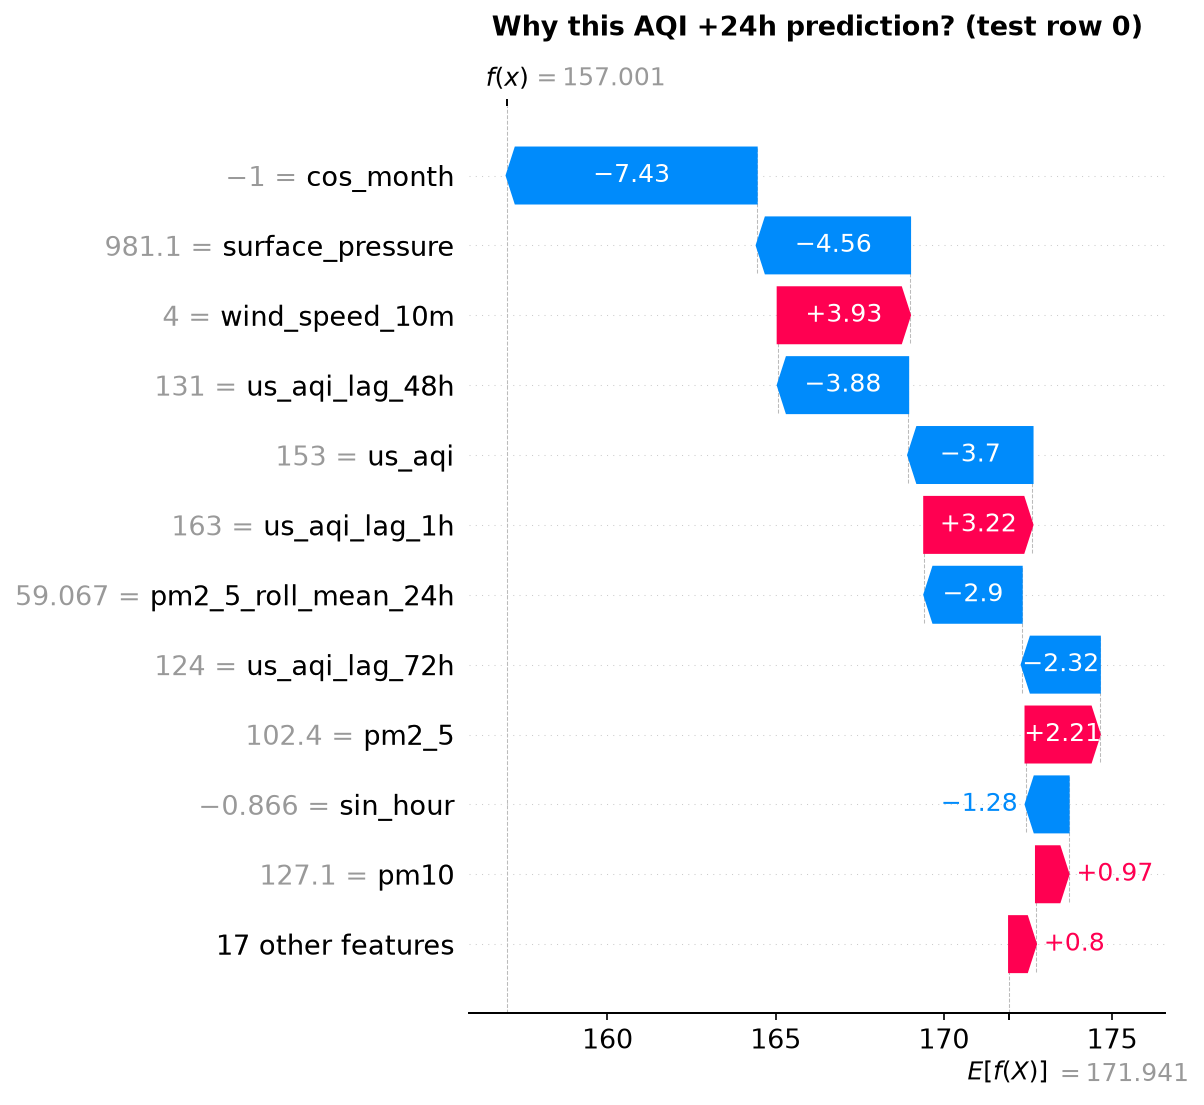

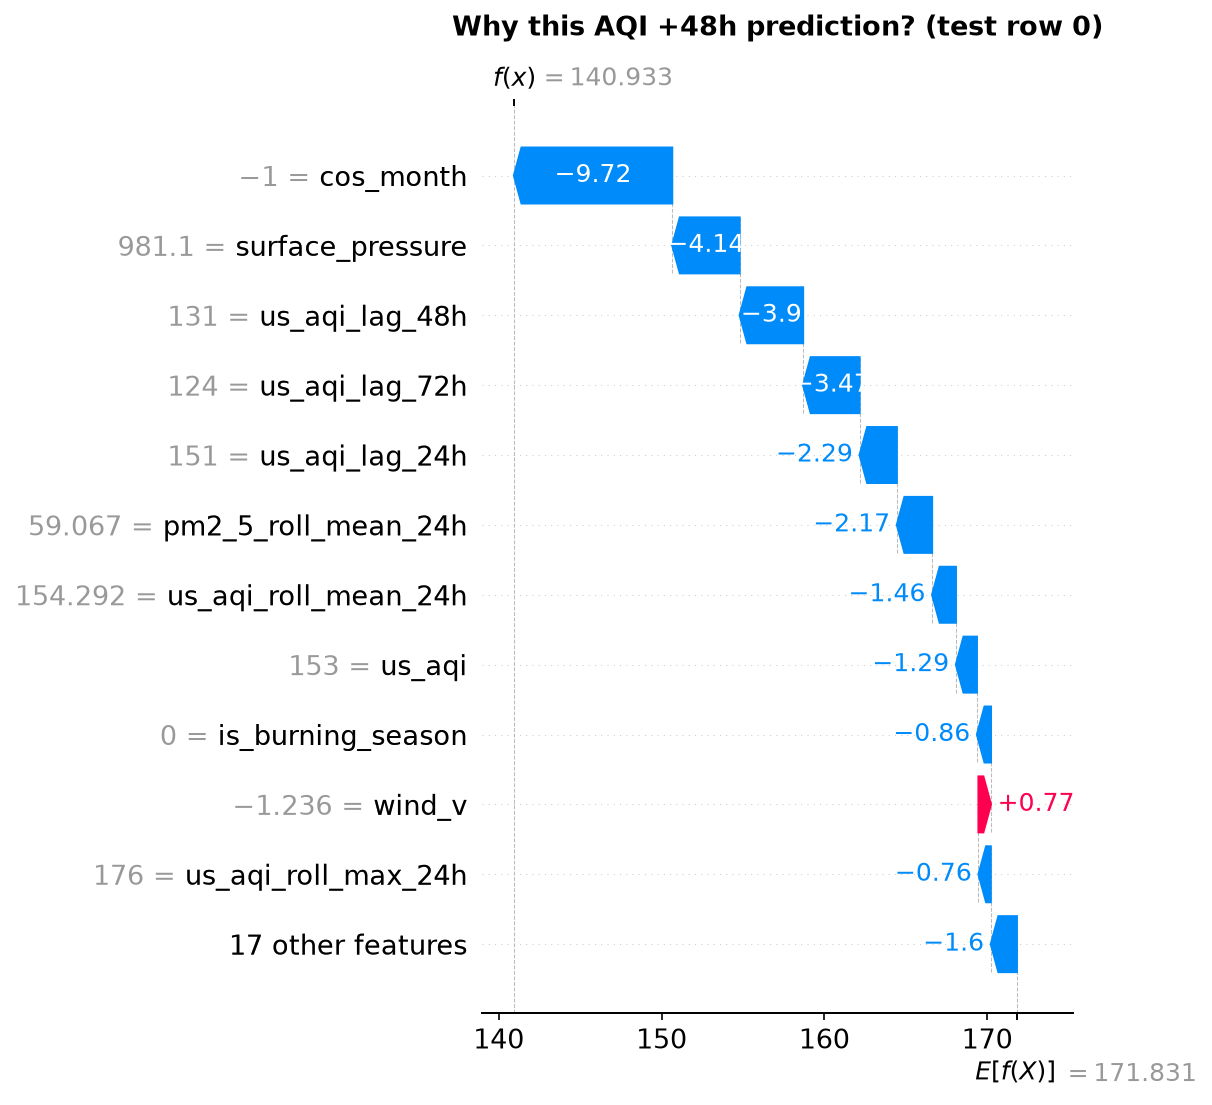

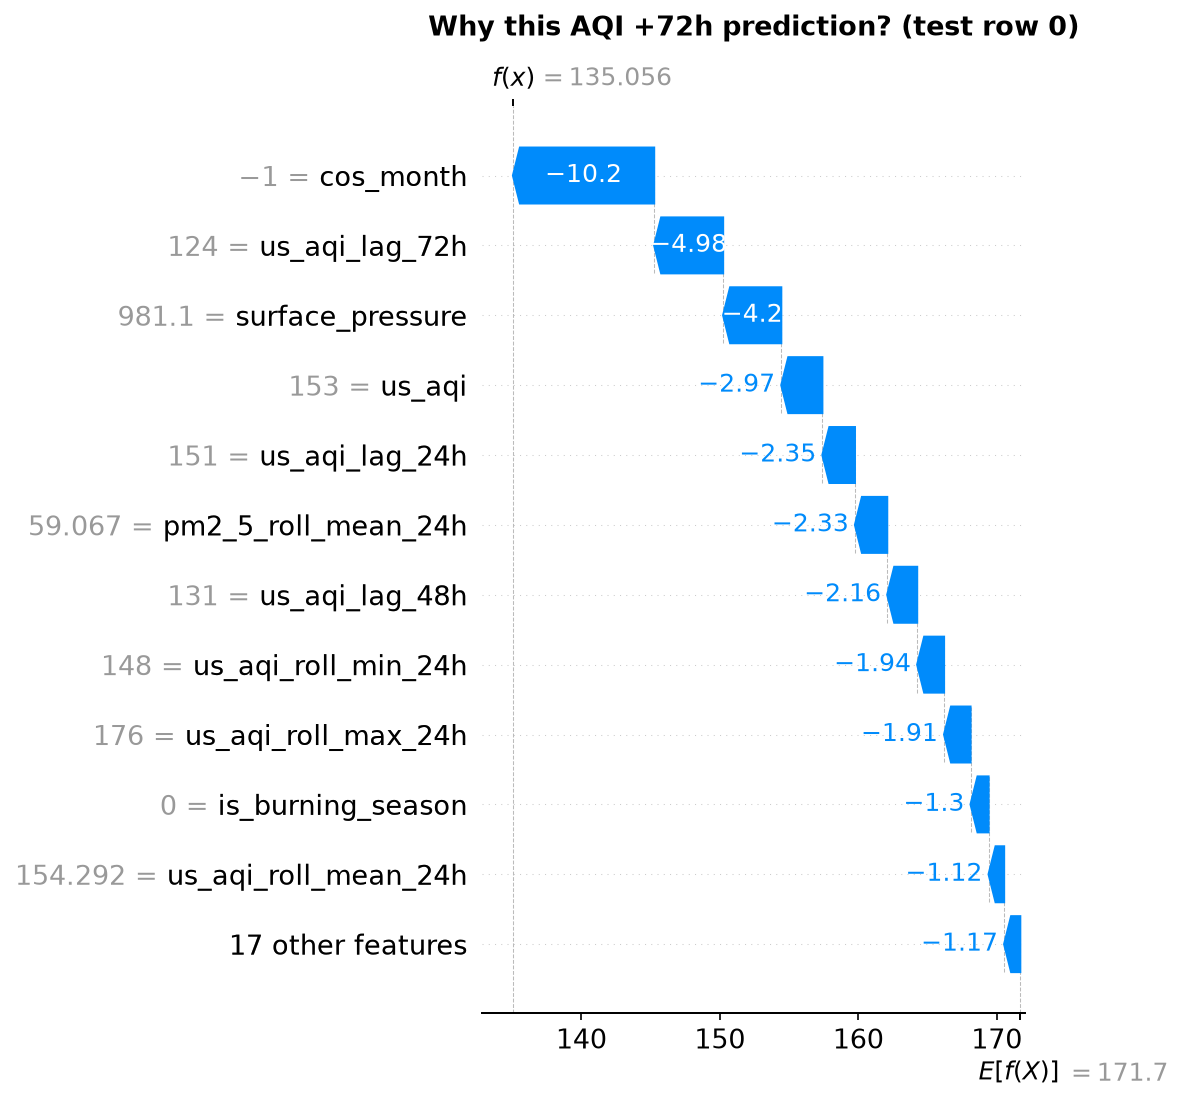

In [28]:
def explain_single_prediction(shap_values, x_data, row_idx, horizon, save_prefix="shap"):
    """Waterfall plot: how each feature pushed one specific prediction up/down from the baseline."""
    fig = plt.figure(figsize=(10, 7))
    shap.plots.waterfall(shap_values[row_idx], max_display=12, show=False)
    plt.title(
        f"Why this AQI +{horizon} prediction? (test row {row_idx})",
        pad=15,
    )
    plt.tight_layout()
    plt.savefig(f"{save_prefix}_waterfall_{horizon}_row{row_idx}.png", dpi=150, bbox_inches="tight")
    plt.show()

# Example: explain the first test-set row for each horizon
explain_single_prediction(shap_values_24h, test_x, row_idx=0, horizon="24h")
explain_single_prediction(shap_values_48h, test_x, row_idx=0, horizon="48h")
explain_single_prediction(shap_values_72h, test_x, row_idx=0, horizon="72h")

<Figure size 1350x900 with 0 Axes>

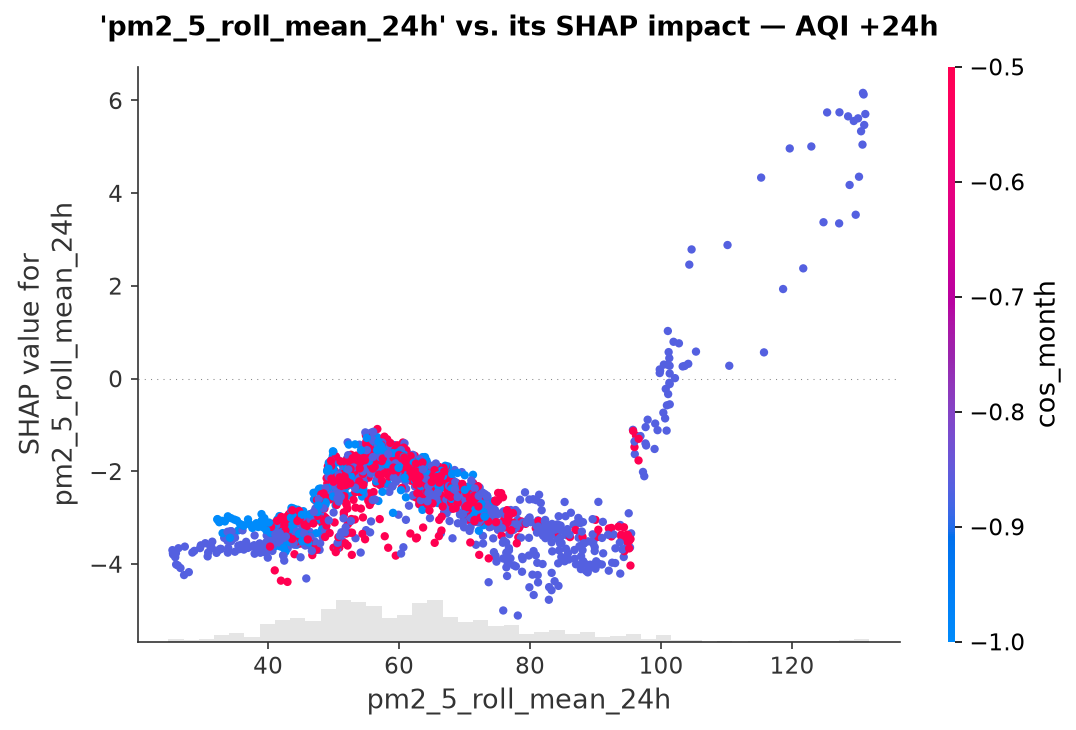

In [29]:
def plot_dependence(shap_values, x_data, feature, horizon, interaction=None, save_prefix="shap"):
    """Shows how SHAP value for `feature` changes as its raw value changes, colored by interaction."""
    fig = plt.figure(figsize=(9, 6))
    shap.plots.scatter(
        shap_values[:, feature],
        color=shap_values[:, interaction] if interaction else shap_values,
        show=False,
    )
    plt.title(f"'{feature}' vs. its SHAP impact — AQI +{horizon}", pad=15)
    plt.tight_layout()
    plt.savefig(f"{save_prefix}_dependence_{feature}_{horizon}.png", dpi=150, bbox_inches="tight")
    plt.show()

# Top feature from your feature_importances_ output was pm2_5_roll_mean_24h
plot_dependence(shap_values_24h, test_x, "pm2_5_roll_mean_24h", "24h", interaction="cos_month")

## 12. Save models and push to the Hopsworks model registry

In [84]:
def save_model_to_registry(project, model, name, metrics, x_sample, y_sample, description):
    """Save a fitted model locally and register it in the Hopsworks model registry."""
    from hsml.schema import Schema
    from hsml.model_schema import ModelSchema

    model_dir = f"artifacts_{name}"
    os.makedirs(model_dir, exist_ok=True)
    joblib.dump(model, os.path.join(model_dir, "model.pkl"))

    input_schema = Schema(x_sample)
    output_schema = Schema(y_sample)
    schema = ModelSchema(input_schema=input_schema, output_schema=output_schema)

    registry = project.get_model_registry()
    entry = registry.python.create_model(
        name=name,
        metrics=metrics,
        description=description,
        model_schema=schema,
        input_example=x_sample,
    )
    entry.save(model_dir, keep_original_files=True)
    print(f"registered {name}")


In [87]:
models_to_register = [
    {
        "name": "aqi_predictor_24h",
        "model": best_cat_24h,
        "y_sample": train_y_24h.head(1),
        "metrics": {"mae": cv_cat_24h["mae"].mean(), "r2": cv_cat_24h["r2"].mean()},
        "description": "24 hour ahead AQI prediction model",
    },
    {
        "name": "aqi_predictor_48h",
        "model": best_cat_48h,
        "y_sample": train_y_48h.head(1),
        "metrics": {"mae": cv_cat_48h["mae"].mean(), "r2": cv_cat_48h["r2"].mean()},
        "description": "48 hour ahead AQI prediction model",
    },
    {
        "name": "aqi_predictor_72h",
        "model": best_cat_72h,
        "y_sample": train_y_72h.head(1),
        "metrics": {"mae": cv_cat_72h["mae"].mean(), "r2": cv_cat_72h["r2"].mean()},
        "description": "72 hour ahead AQI prediction model",
    },
]

x_sample = train_x.head(1)
for cfg in models_to_register:
    save_model_to_registry(project, cfg["model"], cfg["name"], cfg["metrics"], x_sample, cfg["y_sample"], cfg["description"])


  0%|          | 0/6 [00:00<?, ?it/s]

Uploading f:\laptop\AQI_Predictor\artifacts_aqi_predictor_24h/model.pkl: 0.000%|          | 0/653345 elapsed<0…

Uploading C:\Users\Habib\AppData\Local\Temp\tmpe7x7ytmf\input_example.json: 0.000%|          | 0/300 elapsed<0…

Uploading C:\Users\Habib\AppData\Local\Temp\tmpe7x7ytmf\model_schema.json: 0.000%|          | 0/2437 elapsed<0…

Model created, explore it at https://eu-west.cloud.hopsworks.ai:443/p/42119/models/aqi_predictor_24h/3
registered aqi_predictor_24h


...

  0%|          | 0/6 [00:00<?, ?it/s]

Uploading f:\laptop\AQI_Predictor\artifacts_aqi_predictor_72h/model.pkl: 0.000%|          | 0/103221 elapsed<0…

Uploading C:\Users\Habib\AppData\Local\Temp\tmpctk_ph1_\input_example.json: 0.000%|          | 0/300 elapsed<0…

Uploading C:\Users\Habib\AppData\Local\Temp\tmpctk_ph1_\model_schema.json: 0.000%|          | 0/2437 elapsed<0…

Model created, explore it at https://eu-west.cloud.hopsworks.ai:443/p/42119/models/aqi_predictor_72h/2
registered aqi_predictor_72h


## Summary

- Every model is compared against the persistence baseline, not just against each other.
- CatBoost, tuned with time-series cross-validation, was the strongest model at all three horizons.
- All runs (baseline, model comparison, tuning, CV) are logged in MLflow under the `aqi_forecasting`
  experiment - run `mlflow ui` in this notebook's working directory to browse them.
- Report the CV mean MAE/R2 rather than a single test split, since a single split's R2 was shown to
  vary a lot with how volatile that particular window happens to be.
